In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df = pd.read_csv('/content/placement.csv')

In [ ]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [ ]:
df = df.iloc[:,1:]

In [ ]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [ ]:
#EDA phase
import matplotlib.pyplot as plt


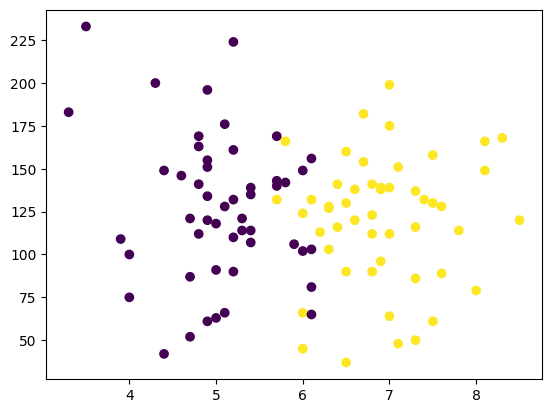

In [ ]:
plt.scatter(df['cgpa'],df['iq'], c=df['placement'])

In [ ]:
 #feature selection

X = df.iloc[:,:2]
y = df.iloc[:,-1]

In [ ]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [ ]:
y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [ ]:
y.shape

(100,)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test,y_train,y_test=train_test_split(X,y,test_size=0.1)

In [ ]:
X_train

,cgpa,iq
56,6.1,65.0
40,4.9,134.0
85,5.8,166.0
21,7.1,151.0
95,4.3,200.0
...,...,...
1,5.9,106.0
71,6.1,132.0
69,8.5,120.0
64,7.0,64.0


In [ ]:
y_train

,placement
56,0
40,0
85,1
21,1
95,0
...,...
1,0
71,1
69,1
64,1


In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()

In [ ]:
X_train_scaled = scaler.fit_transform(X_train)

In [ ]:
X_train_scaled

array([[ 0.07133401, -1.46052393],
       [-0.9558757 ,  0.25497704],
       [-0.18546842,  1.05057169],
       [ 0.9273421 ,  0.67763669],
       [-1.46948055,  1.895891  ],
       [ 0.67053967, -0.83896561],
       [-0.9558757 ,  0.67763669],
       [-0.69907327,  2.49258699],
       [ 0.67053967, -0.29199429],
       [ 1.35534614, -0.86382794],
       [-0.27106923,  1.12515869],
       [ 0.24253563,  0.10580304],
       [ 0.75614048, -0.68979161],
       [ 0.58493886,  1.44836901],
       [-0.69907327,  0.92626002],
       [ 1.78335018,  0.62791203],
       [ 0.67053967, -0.01850863],
       [ 0.9273421 , -1.88318359],
       [-2.32548864,  1.47323135],
       [-1.04147651,  0.42901337],
       [-0.69907327,  0.20525237],
       [ 0.49933805, -0.09309562],
       [ 0.49933805,  0.35442637],
       [ 0.24253563,  0.08094071],
       [ 1.26974533,  0.1555277 ],
       [ 1.9545518 ,  1.10029635],
       [-1.72628298, -0.59034228],
       [ 1.78335018,  1.05057169],
       [-0.78467408,

In [ ]:
X_test_scaled = scaler.transform(X_test)

In [ ]:
X_test_scaled

array([[-0.52787165, -0.41630595],
       [-0.61347246, -0.24226962],
       [ 0.41373724,  0.1555277 ],
       [ 0.84174129, -0.29199429],
       [-0.87027489, -0.14282029],
       [-0.0142668 ,  0.62791203],
       [ 0.67053967,  0.42901337],
       [-0.9558757 ,  1.79644167],
       [-0.0142668 , -0.54061762],
       [-1.12707732, -1.78373426]])

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
clf = LogisticRegression()

In [ ]:
clf.fit(X_train_scaled,y_train)

LogisticRegression()

In [ ]:
y_pred = clf.predict(X_test_scaled)

In [ ]:
y_test

,placement
81,0
46,0
57,1
29,1
67,0
33,0
43,1
80,0
62,0
94,0


In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
accuracy_score(y_test,y_pred)

0.8

In [ ]:
accuracy_score(y_test, y_pred)

0.8

In [ ]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

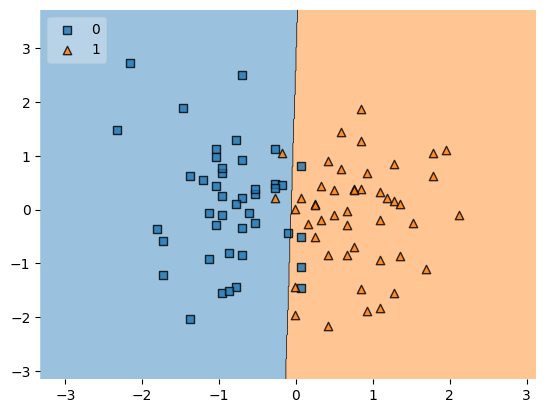

In [ ]:
plot_decision_regions(X_train_scaled, y_train.values, clf=clf, legend=2)

In [ ]:
import pickle

In [ ]:
pickle.dump(clf,open('model.pkl','wb'))